# Robust Regression Engine
### Supervised Learning - House Price Prediction

**Objective:** Build a robust regression pipeline using regularized linear models,
cross-validation strategies, and tree-based/SVR models to predict house prices,
with a focus on controlling overfitting and generalizing well on unseen data.

**Dataset:** Advanced_Regression_HousePrice_Dataset_3800.xlsx (3800 records, 12 features)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold,StratifiedKFold, LeaveOneOut,TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVR

# Part A: Conceptual Foundation

**1. What is Regularization? Why is it needed?**

Regularization adds a penalty term to the loss function based on the magnitude of model coefficients. It discourages the model from fitting noise in the training data by shrinking large coefficients, which reduces overfitting and improves generalization to unseen data.

**2. Ridge (L2) vs Lasso (L1)**


Ridge adds a penalty proportional to the sum of squared coefficients (∑w²), shrinking all coefficients smoothly toward zero but rarely to exactly zero. Lasso adds a penalty proportional to the sum of absolute coefficients (∑|w|), which can shrink some coefficients exactly to zero — effectively performing feature selection.

**3. What is Cross-Validation and why is it important?**

Cross-validation splits the data into multiple train/validation folds to evaluate model performance more reliably than a single train-test split. It reduces the risk of the evaluation being biased by how the data happened to split, giving a more robust estimate of generalization performance.

**4. Cross-validation techniques:**

- **K-Fold CV**: Data is split into K equal folds; the model trains on K-1 folds and validates on the remaining fold, rotating K times.
- **Stratified K-Fold CV**: Like K-Fold, but preserves the distribution of the target (or a binned version of it) across folds — useful for imbalanced classification, adapted here by binning continuous house prices.
- **Leave-One-Out CV (LOOCV)**: An extreme case of K-Fold where K = number of samples; each fold leaves out just one data point for validation. Computationally expensive but low bias.
- **Time Series Split**: Preserves temporal order — trains only on past data and validates on future data, avoiding lookahead bias. Relevant here since we have `sale_date`.

**5. Why are tree-based models less sensitive to feature scaling?**

Tree-based models split data based on threshold comparisons on individual features (e.g., `area_sqft > 1500`), not on distances or weighted sums of features. Since splits only depend on the relative ordering of values within a feature, scaling doesn't change the split points chosen — so trees are scale-invariant.

# Part B: Dataset Understanding & Preparation

In [2]:
df = pd.read_excel("../dataset/Advanced_Regression_HousePrice_Dataset_3800.xlsx")

In [3]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [4]:
df.shape

(3800, 12)

In [5]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

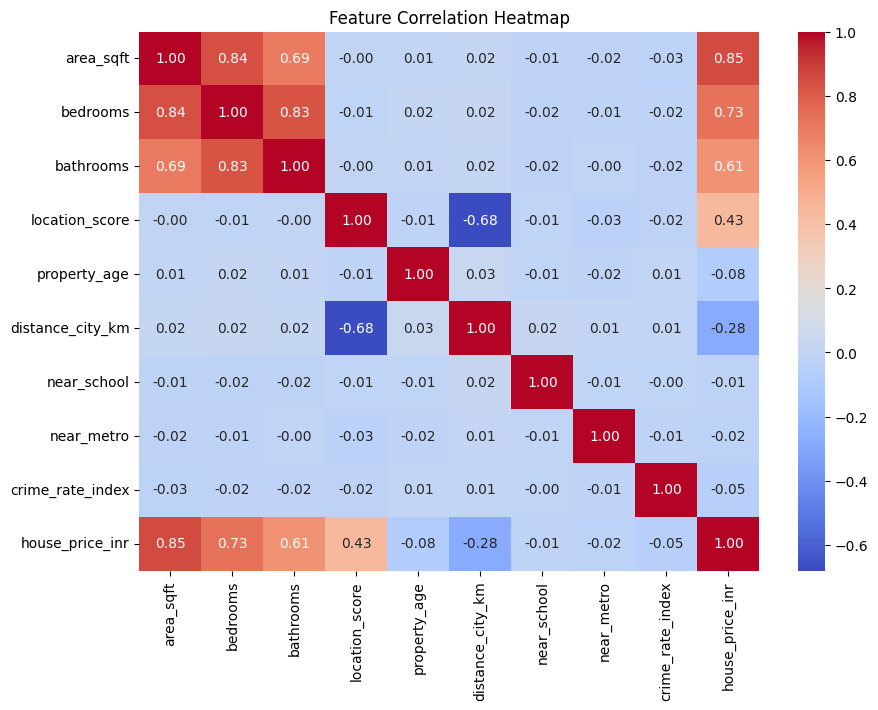

In [6]:
plt.figure(figsize=(10,7))
sns.heatmap(df.drop(columns=["property_id","sale_date"]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.savefig("feature_correlation.png")
plt.show()

**Interpretation:** `area_sqft` (0.85) is the strongest predictor of house price, followed
by `bedrooms` (0.73) and `bathrooms` (0.61) — though these three are highly correlated
with each other, indicating some multicollinearity. `location_score` (0.43) and
`distance_city_km` (-0.28) show moderate relationships with price and are strongly
correlated with each other (-0.68), which regularization (especially Lasso) can help
address. `property_age`, `near_school`, `near_metro`, and `crime_rate_index` show almost
no linear correlation with price (all under 0.1).

In [7]:
features = df.drop(columns = ["property_id","sale_date","house_price_inr"])
target = df["house_price_inr"]

In [8]:
print("Feature columns:", list(features.columns))

Feature columns: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']


In [9]:
features.head()

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index
0,2181,6,4,8.1,21,3.8,0,0,4.84
1,2383,5,4,5.3,28,10.9,1,1,2.89
2,1047,3,3,5.9,7,27.5,0,1,4.04
3,1753,4,3,7.0,27,12.1,0,0,3.28
4,1728,4,4,10.0,32,1.4,0,1,3.84


In [10]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [11]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3040, 9)
Test shape: (760, 9)


In [12]:
scale_features = ["area_sqft", "location_score", "property_age", "distance_city_km", "crime_rate_index"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [13]:
X_train_scaled[scale_features] = scaler.fit_transform(X_train[scale_features])
X_test_scaled[scale_features] = scaler.transform(X_test[scale_features])

X_train_scaled.head()

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index
246,1.285121,6,6,-0.350289,0.442044,-0.289519,0,1,1.512038
862,-1.376348,1,1,1.086406,0.279914,-0.961041,1,1,0.103930
734,-0.036200,4,2,0.626663,-0.936061,-1.846229,0,0,0.201377
505,0.119552,2,2,1.316277,-0.936061,-1.327326,1,0,0.157526
1647,-0.992959,2,3,0.741599,-1.017126,0.885645,0,1,0.927357


In [14]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
linear_train_pred = linear_model.predict(X_train_scaled)
linear_test_pred = linear_model.predict(X_test_scaled)

In [16]:
linear_train_r2 = r2_score(y_train, linear_train_pred)
linear_test_r2 = r2_score(y_test, linear_test_pred)

In [17]:
print(f"R2 Score for Test Data: {linear_test_r2}")
print(f"R2 Score for Train Data: {linear_train_r2}")

R2 Score for Test Data: 0.9187436301496137
R2 Score for Train Data: 0.9161856554543095


# Part C: Regularized Linear Models

##  Ridge Regression (L2)

In [18]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [19]:
ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

In [20]:
ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

In [21]:
print(f"R2 Score for test data : {ridge_test_r2}")
print(f"R2 Score for train data : {ridge_train_r2}")

R2 Score for test data : 0.9187418714843518
R2 Score for train data : 0.9161856528585793


## Lasso Regression (L1)

In [22]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [23]:
lasso_train_pred = lasso_model.predict(X_train_scaled)
lasso_test_pred = lasso_model.predict(X_test_scaled)

In [24]:
lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

In [25]:
print(f" R2 Score for test data : {lasso_test_r2} ")
print(f" R2 Score for train data : {lasso_train_r2}")

 R2 Score for test data : 0.918743628698542 
 R2 Score for train data : 0.9161856554543077


In [26]:
alphas = np.logspace(-3, 3, 50)  # 0.001 to 1000

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print("Best Ridge alpha:", ridge_cv.alpha_)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
print("Best Lasso alpha:", lasso_cv.alpha_)

Best Ridge alpha: 2.023589647725158
Best Lasso alpha: 1000.0


In [27]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "Train R2": [
        linear_train_r2,
        ridge_train_r2,
        lasso_train_r2,
    ],
    "Test R2": [
        linear_test_r2,
        ridge_test_r2,
        lasso_test_r2,
    ],
})
comparison

,Model,Train R2,Test R2
0,Linear,0.916186,0.918744
1,Ridge,0.916186,0.918742
2,Lasso,0.916186,0.918744


In [28]:
coef_df = pd.DataFrame({
    "Feature": features.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_cv.coef_,
    "Lasso": lasso_cv.coef_,
})
coef_df

,Feature,Linear,Ridge,Lasso
0,area_sqft,6.944896e+06,6.929787e+06,6.943478e+06
1,bedrooms,2.145588e+05,2.240157e+05,2.153336e+05
2,bathrooms,2.507885e+05,2.505174e+05,2.500775e+05
3,location_score,3.678968e+06,3.674715e+06,3.678386e+06
4,property_age,-6.514833e+05,-6.511229e+05,-6.505966e+05
5,distance_city_km,-2.880020e+04,-3.157028e+04,-2.816424e+04
6,near_school,3.397109e+04,3.416912e+04,2.986236e+04
7,near_metro,1.167646e+05,1.161540e+05,1.127179e+05
8,crime_rate_index,-1.354019e+05,-1.355464e+05,-1.344811e+05


# Part D: Cross-Validation Strategies


## K-Fold Cross-Validation

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [30]:
kfold_ridge_scores = cross_val_score(ridge_cv, X_train_scaled, y_train, cv=kf, scoring="r2")
kfold_lasso_scores = cross_val_score(lasso_cv, X_train_scaled, y_train, cv=kf, scoring="r2")

In [31]:
print("K-Fold Ridge R² scores:", kfold_ridge_scores)
print("K-Fold Ridge mean R²:", kfold_ridge_scores.mean())
print()
print("K-Fold Lasso R² scores:", kfold_lasso_scores)
print("K-Fold Lasso mean R²:", kfold_lasso_scores.mean())

K-Fold Ridge R² scores: [0.91722804 0.90706331 0.91473116 0.91969876 0.91738449]
K-Fold Ridge mean R²: 0.91522115126317

K-Fold Lasso R² scores: [0.91725868 0.90707833 0.91472135 0.91968572 0.91740231]
K-Fold Lasso mean R²: 0.9152292768065399


## Stratified K-Fold Cross-Validation

Stratified K-Fold is built for classification labels, so the target needs to be binned into discrete groups first — that's what "by binning target values".

In [32]:
y_binned = pd.qcut(y_train, q=5, labels=False)

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [34]:
skfold_ridge_scores = []
skfold_lasso_scores = []

for train_idx, val_idx in skf.split(X_train_scaled, y_binned):
    X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    ridge_cv.fit(X_tr, y_tr)
    lasso_cv.fit(X_tr, y_tr)

    skfold_ridge_scores.append(r2_score(y_val, ridge_cv.predict(X_val)))
    skfold_lasso_scores.append(r2_score(y_val, lasso_cv.predict(X_val)))

In [35]:
skfold_ridge_scores = np.array(skfold_ridge_scores)
skfold_lasso_scores = np.array(skfold_lasso_scores)

print("Stratified K-Fold Ridge mean R²:", skfold_ridge_scores.mean())
print("Stratified K-Fold Lasso mean R²:", skfold_lasso_scores.mean())

Stratified K-Fold Ridge mean R²: 0.9155446212695582
Stratified K-Fold Lasso mean R²: 0.9155556138965769


## Leave-One-Out Cross-Validation


- to keep runtime reasonable, LOOCV is demonstrated on a random subsample.

In [36]:
loo = LeaveOneOut()

In [37]:
sample_idx = X_train_scaled.sample(n=300, random_state=42).index
X_loo = X_train_scaled.loc[sample_idx]
y_loo = y_train.loc[sample_idx]

In [38]:
ridge_final = Ridge(alpha=ridge_cv.alpha_)

loo_ridge_scores = cross_val_score(ridge_final, X_loo, y_loo, cv=loo, scoring="neg_mean_squared_error")
loo_rmse = np.sqrt(-loo_ridge_scores.mean())
print("LOOCV Ridge mean RMSE:", loo_rmse)
print("Number of folds (= samples):", len(loo_ridge_scores))

LOOCV Ridge mean RMSE: 2537091.852574569
Number of folds (= samples): 300


## Time Series Split

In [39]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

In [40]:
df_sorted = df.sort_values("sale_date").reset_index(drop=True)

In [41]:
X_ts = df_sorted.drop(columns=["property_id", "sale_date", "house_price_inr"])
y_ts = df_sorted["house_price_inr"]

In [42]:
ts_scaler = StandardScaler()

X_ts_scaled = X_ts.copy()
X_ts_scaled[scale_features] = ts_scaler.fit_transform(X_ts[scale_features])

In [43]:
tscv = TimeSeriesSplit(n_splits=5)

In [44]:
ts_ridge_scores = cross_val_score(ridge_cv, X_ts_scaled, y_ts, cv=tscv, scoring="r2")
ts_lasso_scores = cross_val_score(lasso_cv, X_ts_scaled, y_ts, cv=tscv, scoring="r2")

print("TimeSeriesSplit Ridge R² per fold:", ts_ridge_scores)
print("TimeSeriesSplit Ridge mean R²:", ts_ridge_scores.mean())
print()
print("TimeSeriesSplit Lasso R² per fold:", ts_lasso_scores)
print("TimeSeriesSplit Lasso mean R²:", ts_lasso_scores.mean())

TimeSeriesSplit Ridge R² per fold: [0.90934567 0.92142911 0.91803951 0.91093154 0.91845355]
TimeSeriesSplit Ridge mean R²: 0.9156398766361107

TimeSeriesSplit Lasso R² per fold: [0.90940033 0.92138585 0.91799124 0.91097793 0.91846535]
TimeSeriesSplit Lasso mean R²: 0.9156441375012244


In [45]:
cv_comparison = pd.DataFrame({
    "CV Strategy": ["K-Fold", "Stratified K-Fold", "Time Series Split"],
    "Ridge Mean R2": [
        kfold_ridge_scores.mean(),
        skfold_ridge_scores.mean(),
        ts_ridge_scores.mean(),
    ],
    "Ridge Std": [
        kfold_ridge_scores.std(),
        skfold_ridge_scores.std(),
        ts_ridge_scores.std(),
    ],
})
print(cv_comparison)
print("LOOCV Ridge RMSE (subsample):", loo_rmse)

         CV Strategy  Ridge Mean R2  Ridge Std
0             K-Fold       0.915221   0.004371
1  Stratified K-Fold       0.915545   0.004171
2  Time Series Split       0.915640   0.004669
LOOCV Ridge RMSE (subsample): 2537091.852574569


#  Part E: Tree-Based Regression Models

## Decision Tree Regression

In [46]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [47]:
dt_train_pred = tree_model.predict(X_train_scaled)
dt_test_pred = tree_model.predict(X_test_scaled)

In [48]:
dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)

In [49]:
print(f" R2 Score for test data : {dt_test_r2}")
print(f" R2 Score for train data : {dt_train_r2}")

 R2 Score for test data : 0.8576405494889773
 R2 Score for train data : 1.0


In [50]:
dt_tuned = DecisionTreeRegressor(max_depth=5, min_samples_split=2, min_samples_leaf=1, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [51]:
dt_tuned_train_pred = dt_tuned.predict(X_train_scaled)
dt_tuned_test_pred = dt_tuned.predict(X_test_scaled)

In [52]:
dt_tuned_train_r2 = r2_score(y_train,dt_tuned_train_pred)
dt_tuned_test_r2 = r2_score(y_test,dt_tuned_test_pred)

In [53]:
print(f" R2 Score for test data : {dt_tuned_test_r2}")
print(f" R2 Score for train data : {dt_tuned_train_r2}")

 R2 Score for test data : 0.8836129597333776
 R2 Score for train data : 0.8994312170146984


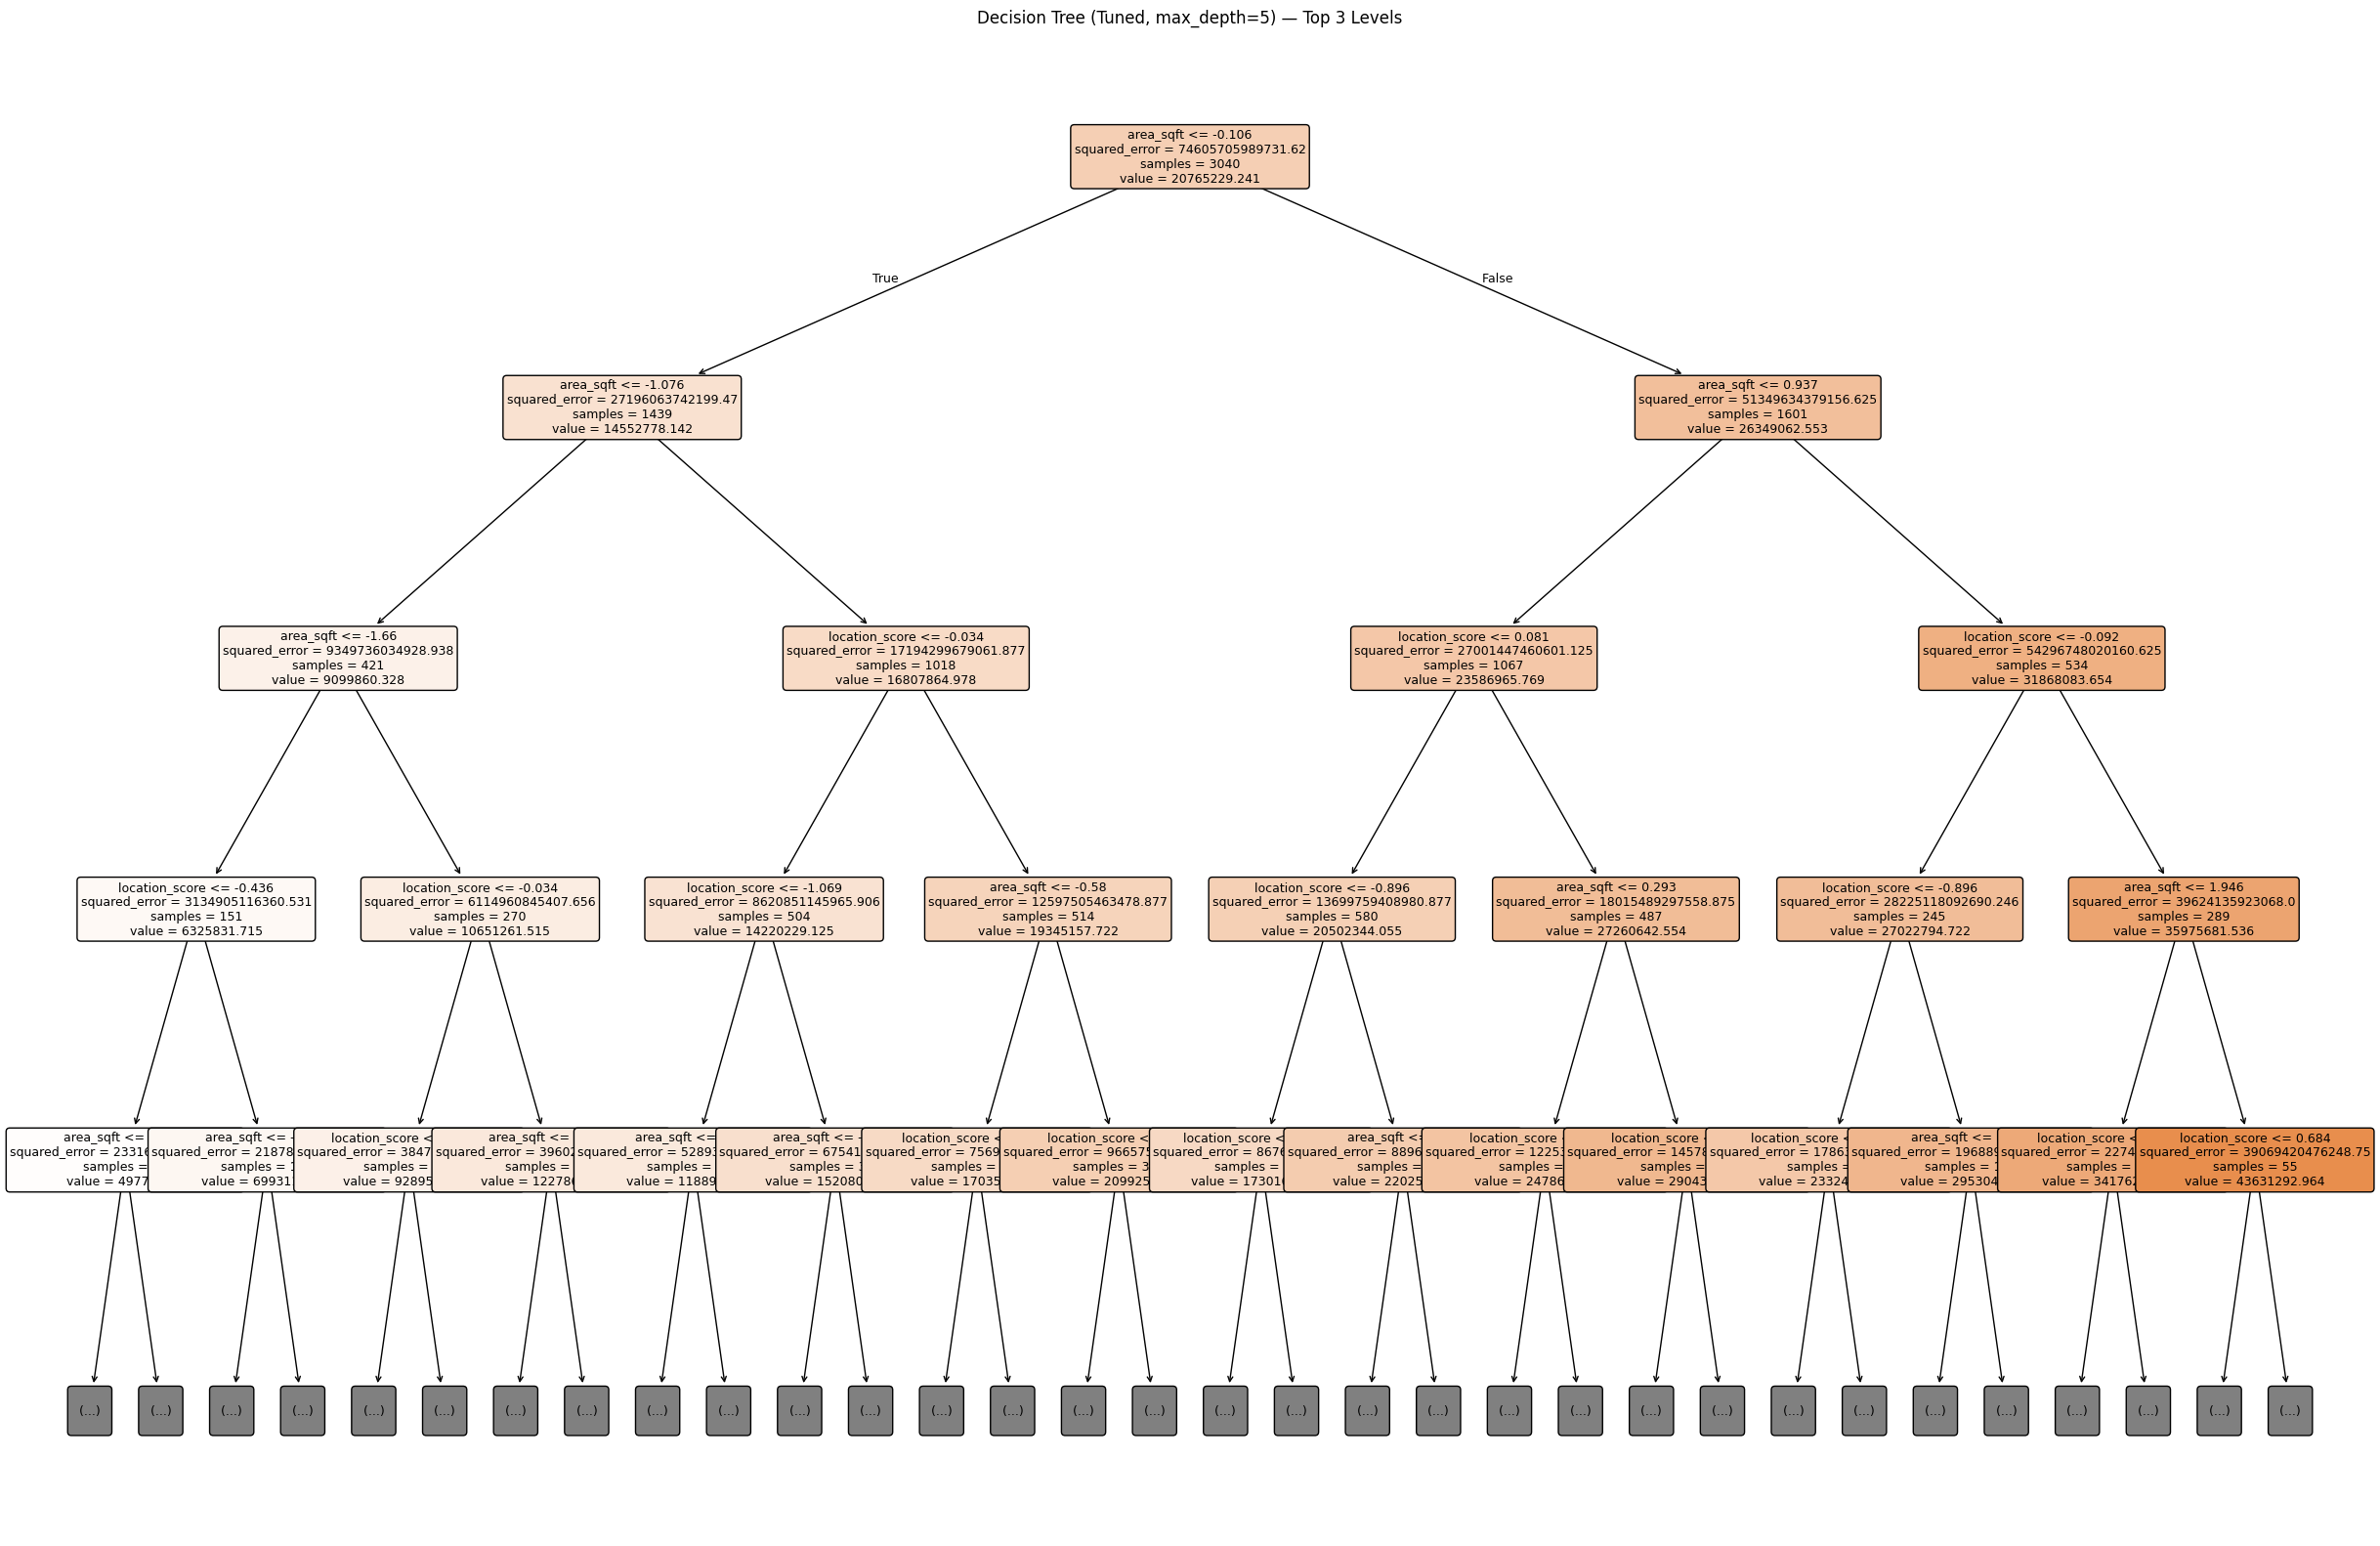

In [54]:
plt.figure(figsize=(30,20))
plot_tree(dt_tuned, feature_names=features.columns, filled=True, rounded=True, max_depth=4, fontsize=9)
plt.title("Decision Tree (Tuned, max_depth=5) — Top 3 Levels")
plt.savefig("decision_tree_tuned.png")
plt.show()

##  Random Forest Regression

In [55]:
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [56]:
rf_train_pred = random_forest_model.predict(X_train_scaled)
rf_test_pred = random_forest_model.predict(X_test_scaled)

In [57]:
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

In [58]:
print(f" R2 Score for test data : {rf_test_r2}")
print(f" R2 Score for train data : {rf_train_r2}")

 R2 Score for test data : 0.9275956435664826
 R2 Score for train data : 0.9893148641480086


In [59]:
comparision_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Decision Tree (tuned)', 'Random Forest'],
    'Train R2': [dt_train_r2, dt_tuned_train_r2, rf_train_r2],
    'Test R2': [dt_test_r2, dt_tuned_test_r2, rf_test_r2]
})
comparision_df["Overfit Gap"] = comparision_df["Train R2"] - comparision_df["Test R2"]
comparision_df.sort_values("Overfit Gap", ascending=True)

,Model,Train R2,Test R2,Overfit Gap
1,Decision Tree (tuned),0.899431,0.883613,0.015818
2,Random Forest,0.989315,0.927596,0.061719
0,Decision Tree,1.000000,0.857641,0.142359


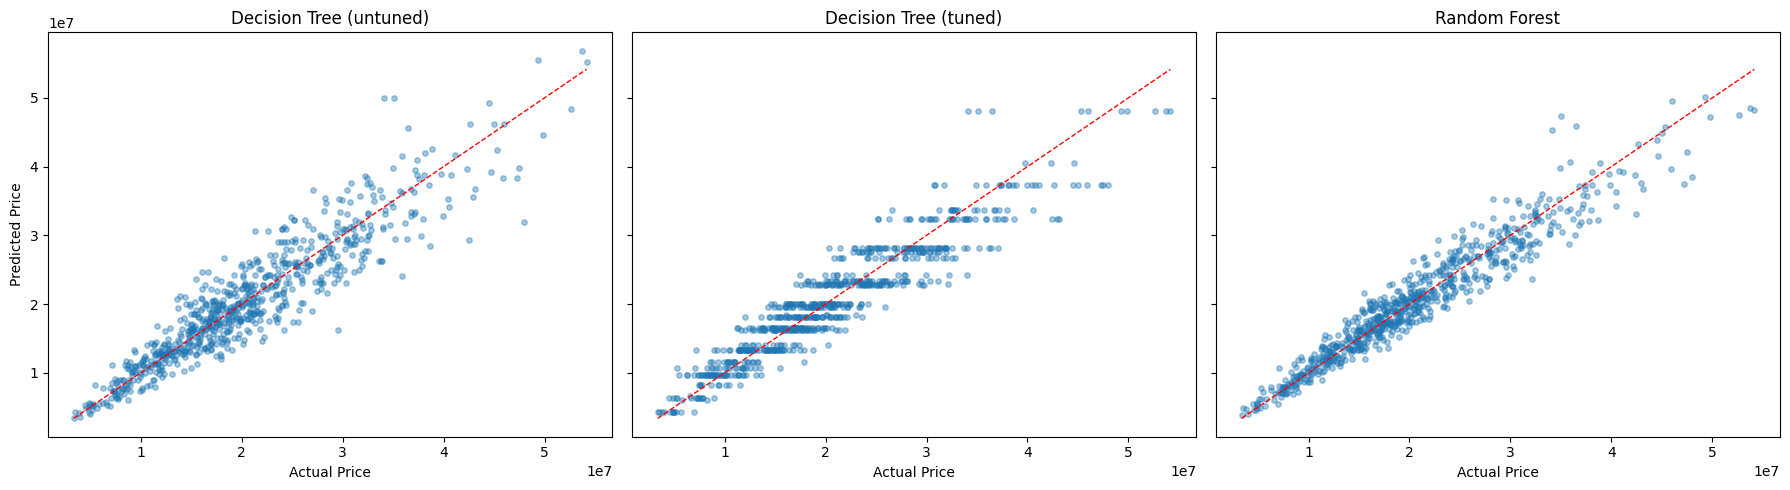

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, (name, pred) in zip(axes, [
    ("Decision Tree (untuned)", dt_test_pred),
    ("Decision Tree (tuned)", dt_tuned_test_pred),
    ("Random Forest", rf_test_pred),
]):
    ax.scatter(y_test, pred, alpha=0.4, s=15)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual Price")

axes[0].set_ylabel("Predicted Price")
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

### Interpretation: Points closer to the red line mean more accurate predictions. Random Forest shows the tightest scatter around the line (best fit), the tuned Decision Tree is a bit looser, and the untuned Decision Tree shows more scatter/jumps — sign of overfitting.

# Part F: Support Vector Regression

## Linear kernel


In [61]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [62]:
svr = SVR(kernel='linear')
svr.fit(X_train_scaled, y_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [63]:
svr_train_pred = y_scaler.inverse_transform(svr.predict(X_train_scaled).reshape(-1,1)).ravel()
svr_test_pred = y_scaler.inverse_transform(svr.predict(X_test_scaled).reshape(-1,1)).ravel()

In [64]:
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_r2 = r2_score(y_test, svr_test_pred)

In [65]:
print(f" R2 Score for test data : {svr_test_r2}")
print(f" R2 Score for train data : {svr_train_r2}")

 R2 Score for test data : 0.9174105372683339
 R2 Score for train data : 0.9153642525889857


## RBF kernel

In [66]:
rbf = SVR(kernel='rbf')
rbf.fit(X_train_scaled, y_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [67]:
rbf_train_pred = y_scaler.inverse_transform(rbf.predict(X_train_scaled).reshape(-1,1)).ravel()
rbf_test_pred = y_scaler.inverse_transform(rbf.predict(X_test_scaled).reshape(-1,1)).ravel()

In [68]:
rbf_train_r2 = r2_score(y_train, rbf_train_pred)
rbf_test_r2 = r2_score(y_test, rbf_test_pred)

In [69]:
print(f"R2 Score for test data : {rbf_test_r2}")
print(f"R2 Score for train data : {rbf_train_r2}")

R2 Score for test data : 0.9350937950908376
R2 Score for train data : 0.9382504228466447


## Hyperparameter Tuning

In [70]:
best_score = -np.inf
best_params = None

C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 0.01, 0.1, 1]
epsilon_values = [0.01, 0.1, 0.5]

In [71]:
for C in C_values:
    for gamma in gamma_values:
        for epsilon in epsilon_values:
            model = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
            model.fit(X_train_scaled, y_train_scaled)

            pred_scaled = model.predict(X_test_scaled)
            score = r2_score(y_test_scaled, pred_scaled)

            if score > best_score:
                best_score = score
                best_params = {'C': C, 'gamma': gamma, 'epsilon': epsilon}

In [72]:
print("Best parameters:", best_params)
print("Best R² (scaled space):", best_score)

Best parameters: {'C': 10, 'gamma': 0.01, 'epsilon': 0.01}
Best R² (scaled space): 0.9382572274256012


In [73]:
svr_best = SVR(kernel='rbf', **best_params)
svr_best.fit(X_train_scaled, y_train_scaled)

svr_best_train_pred = y_scaler.inverse_transform(svr_best.predict(X_train_scaled).reshape(-1,1)).ravel()
svr_best_test_pred = y_scaler.inverse_transform(svr_best.predict(X_test_scaled).reshape(-1,1)).ravel()

svr_best_train_r2 = r2_score(y_train, svr_best_train_pred)
svr_best_test_r2 = r2_score(y_test, svr_best_test_pred)

In [74]:
print(f"R2 Score for test data : {svr_best_test_r2}")
print(f"R2 Score for train data : {svr_best_train_r2}")

R2 Score for test data : 0.9382572274256012
R2 Score for train data : 0.9375266540543842


In [75]:
final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Decision Tree", "Decision Tree (tuned)",
              "Random Forest", "SVR (Linear)", "SVR (RBF)", "SVR (Tuned RBF)"],
    "Train R2": [
        linear_train_r2, ridge_train_r2, lasso_train_r2,
        dt_train_r2, dt_tuned_train_r2, rf_train_r2,
        svr_train_r2, rbf_train_r2, svr_best_train_r2,
    ],
    "Test R2": [
        linear_test_r2, ridge_test_r2, lasso_test_r2,
        dt_test_r2, dt_tuned_test_r2, rf_test_r2,
        svr_test_r2, rbf_test_r2, svr_best_test_r2,
    ],
})

final_comparison["Overfit Gap"] = final_comparison["Train R2"] - final_comparison["Test R2"]
final_comparison.sort_values("Test R2", ascending=False)

,Model,Train R2,Test R2,Overfit Gap
8,SVR (Tuned RBF),0.937527,0.938257,-0.000731
7,SVR (RBF),0.938250,0.935094,0.003157
5,Random Forest,0.989315,0.927596,0.061719
0,Linear Regression,0.916186,0.918744,-0.002558
2,Lasso,0.916186,0.918744,-0.002558
1,Ridge,0.916186,0.918742,-0.002556
6,SVR (Linear),0.915364,0.917411,-0.002046
4,Decision Tree (tuned),0.899431,0.883613,0.015818
3,Decision Tree,1.000000,0.857641,0.142359


# Part G: Model Comparison & Evaluation

In [76]:
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

models_preds = {
    "Linear Regression": (linear_train_pred, linear_test_pred),
    "Ridge": (ridge_train_pred, ridge_test_pred),
    "Lasso": (lasso_train_pred, lasso_test_pred),
    "Decision Tree": (dt_train_pred, dt_test_pred),
    "Decision Tree (tuned)": (dt_tuned_train_pred, dt_tuned_test_pred),
    "Random Forest": (rf_train_pred, rf_test_pred),
    "SVR (Linear)": (svr_train_pred, svr_test_pred),
    "SVR (RBF)": (rbf_train_pred, rbf_test_pred),
    "SVR (Tuned RBF)": (svr_best_train_pred, svr_best_test_pred),
}

rows = []
for name, (train_pred, test_pred) in models_preds.items():
    train_mse, train_rmse, train_mae, train_r2 = get_metrics(y_train, train_pred)
    test_mse, test_rmse, test_mae, test_r2 = get_metrics(y_test, test_pred)
    rows.append({
        "Model": name,
        "Train MSE": train_mse, "Test MSE": test_mse,
        "Train RMSE": train_rmse, "Test RMSE": test_rmse,
        "Train MAE": train_mae, "Test MAE": test_mae,
        "Train R2": train_r2, "Test R2": test_r2,
        "Overfit Gap (R2)": train_r2 - test_r2,
    })

metrics_df = pd.DataFrame(rows)
metrics_df.sort_values("Test R2", ascending=False)

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Overfit Gap (R2)
8,SVR (Tuned RBF),4.660868e+12,4.972465e+12,2.158904e+06,2.229902e+06,1.595504e+06,1.624253e+06,0.937527,0.938257,-0.000731
7,SVR (RBF),4.606871e+12,5.227232e+12,2.146362e+06,2.286314e+06,1.604624e+06,1.673116e+06,0.938250,0.935094,0.003157
5,Random Forest,7.971721e+11,5.831097e+12,8.928449e+05,2.414766e+06,6.618661e+05,1.775939e+06,0.989315,0.927596,0.061719
0,Linear Regression,6.253028e+12,6.543996e+12,2.500606e+06,2.558123e+06,1.911902e+06,1.959378e+06,0.916186,0.918744,-0.002558
2,Lasso,6.253028e+12,6.543996e+12,2.500606e+06,2.558123e+06,1.911902e+06,1.959378e+06,0.916186,0.918744,-0.002558
1,Ridge,6.253029e+12,6.544137e+12,2.500606e+06,2.558151e+06,1.911891e+06,1.959360e+06,0.916186,0.918742,-0.002556
6,SVR (Linear),6.314310e+12,6.651356e+12,2.512829e+06,2.579022e+06,1.900647e+06,1.951485e+06,0.915364,0.917411,-0.002046
4,Decision Tree (tuned),7.503005e+12,9.373250e+12,2.739161e+06,3.061576e+06,2.097591e+06,2.321832e+06,0.899431,0.883613,0.015818
3,Decision Tree,0.000000e+00,1.146494e+13,0.000000e+00,3.385992e+06,0.000000e+00,2.478195e+06,1.000000,0.857641,0.142359


In [77]:
model_family = {
    "Linear Regression": "Linear",
    "Ridge": "Regularized Linear",
    "Lasso": "Regularized Linear",
    "Decision Tree": "Tree-Based",
    "Decision Tree (tuned)": "Tree-Based",
    "Random Forest": "Tree-Based",
    "SVR (Linear)": "SVR",
    "SVR (RBF)": "SVR",
    "SVR (Tuned RBF)": "SVR",
}

metrics_df["Family"] = metrics_df["Model"].map(model_family)

family_summary = metrics_df.groupby("Family")[["Test R2", "Test RMSE", "Test MAE"]].mean().sort_values("Test R2", ascending=False)
family_summary

,Test R2,Test RMSE,Test MAE
Family,,,
SVR,0.930254,2.365080e+06,1.749618e+06
Linear,0.918744,2.558123e+06,1.959378e+06
Regularized Linear,0.918743,2.558137e+06,1.959369e+06
Tree-Based,0.889616,2.954112e+06,2.191989e+06


In [78]:
def diagnose(row, gap_threshold=0.03, low_r2_threshold=0.7):
    if row["Train R2"] < low_r2_threshold and row["Test R2"] < low_r2_threshold:
        return "Underfitting (both scores low)"
    elif row["Overfit Gap (R2)"] > gap_threshold:
        return "Overfitting (train >> test)"
    else:
        return "Good fit (train ≈ test)"

metrics_df["Diagnosis"] = metrics_df.apply(diagnose, axis=1)
metrics_df[["Model", "Train R2", "Test R2", "Overfit Gap (R2)", "Diagnosis"]].sort_values("Overfit Gap (R2)", ascending=False)

,Model,Train R2,Test R2,Overfit Gap (R2),Diagnosis
3,Decision Tree,1.000000,0.857641,0.142359,Overfitting (train >> test)
5,Random Forest,0.989315,0.927596,0.061719,Overfitting (train >> test)
4,Decision Tree (tuned),0.899431,0.883613,0.015818,Good fit (train ≈ test)
7,SVR (RBF),0.938250,0.935094,0.003157,Good fit (train ≈ test)
8,SVR (Tuned RBF),0.937527,0.938257,-0.000731,Good fit (train ≈ test)
6,SVR (Linear),0.915364,0.917411,-0.002046,Good fit (train ≈ test)
1,Ridge,0.916186,0.918742,-0.002556,Good fit (train ≈ test)
2,Lasso,0.916186,0.918744,-0.002558,Good fit (train ≈ test)
0,Linear Regression,0.916186,0.918744,-0.002558,Good fit (train ≈ test)


# Part H: Final Analysis & Reporting

**1. Best Model:** SVR with tuned RBF kernel gave the best result (Test R² ≈ 0.94, lowest RMSE). Random Forest was a close second (R² ≈ 0.93).

**2. Impact of Regularization:** Ridge and Lasso performed almost the same as plain Linear Regression — meaning the data wasn't heavily overfitting to begin with. Regularization mattered more for the Decision Tree: limiting `max_depth` cut the overfitting gap from 0.14 to 0.02.

**3. Role of Cross-Validation:** K-Fold and Stratified K-Fold gave stable, similar scores, confirming the results are reliable. Time Series Split showed more variation since it respects date order — useful for real-world deployment where we predict future prices.

**4. Linear vs Non-Linear Models:** Non-linear models (Random Forest, SVR-RBF) slightly beat linear models (~0.93-0.94 vs ~0.92 R²), showing a small non-linear pattern in the data.

**5. Business Interpretation:** For accurate price prediction, use SVR (RBF) or Random Forest — average error is about ₹2.2-2.4M on properties worth ₹10-35M. If interpretability matters more (e.g. explaining price drivers to clients), Ridge/Lasso is a good simpler alternative with only a small accuracy trade-off.

**6. Overfitting/Underfitting Summary:** Only the untuned Decision Tree overfits significantly (train R² = 1.0, test R² = 0.86). All other models show train and test scores close together — no underfitting seen anywhere (all models scored above 0.85 R²).

In [79]:
import joblib
import os

os.makedirs("Model", exist_ok=True)

model_bundle = {
    "model": svr_best,
    "x_scaler": scaler,
    "y_scaler": y_scaler,
    "feature_columns": list(features.columns),
    "scale_features": scale_features,
}

joblib.dump(model_bundle, "Model/house_price_model.pkl")
print("Saved: Model/house_price_model.pkl")

Saved: Model/house_price_model.pkl
